In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

SEED = 42

tf.keras.utils.set_random_seed(SEED)

tf.config.experimental.enable_op_determinism()

print("TensorFlow version:", tf.__version__)
print("Random seed:", SEED)

TensorFlow version: 2.20.0
Random seed: 42


In [ ]:
(x_train_raw, y_train), (x_test_raw, y_test) = tf.keras.datasets.mnist.load_data()

print("Training images:", x_train_raw.shape)
print("Training labels:", y_train.shape)
print("Test images:", x_test_raw.shape)
print("Test labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


In [ ]:
x_train = x_train_raw.astype("float32") / 255.0
x_test = x_test_raw.astype("float32") / 255.0

# MNIST images are grayscale, so the channel dimension is 1.
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

print("Processed training images:", x_train.shape)
print("Processed test images:", x_test.shape)

Processed training images: (60000, 28, 28, 1)
Processed test images: (10000, 28, 28, 1)


In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(32, kernel_size=3, activation="relu"),
    tf.keras.layers.MaxPooling2D(pool_size=2),
    tf.keras.layers.Conv2D(64, kernel_size=3, activation="relu"),
    tf.keras.layers.MaxPooling2D(pool_size=2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax"),
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history = model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=5,
    validation_split=0.1,
    shuffle=True,
    verbose=1,
)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 92ms/step - accuracy: 0.9281 - loss: 0.2492 - val_accuracy: 0.9812 - val_loss: 0.0639
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 91ms/step - accuracy: 0.9791 - loss: 0.0672 - val_accuracy: 0.9862 - val_loss: 0.0480
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 37s 88ms/step - accuracy: 0.9854 - loss: 0.0474 - val_accuracy: 0.9875 - val_loss: 0.0404
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 90ms/step - accuracy: 0.9887 - loss: 0.0358 - val_accuracy: 0.9887 - val_loss: 0.0376
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 37s 88ms/step - accuracy: 0.9911 - loss: 0.0286 - val_accuracy: 0.9895 - val_loss: 0.0361


In [ ]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4%}")

Test loss:     0.0333
Test accuracy: 98.9300%


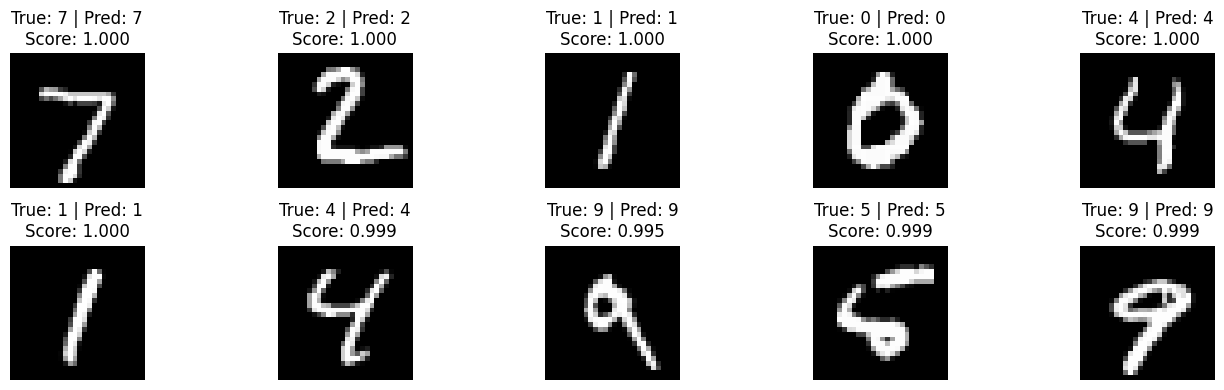

In [ ]:
sample_count = 10
sample_images = x_test[:sample_count]
sample_labels = y_test[:sample_count]

probabilities = model.predict(sample_images, verbose=0)
predicted_labels = np.argmax(probabilities, axis=1)
top_scores = np.max(probabilities, axis=1)

plt.figure(figsize=(14, 4))

for i in range(sample_count):
    plt.subplot(2, 5, i + 1)
    plt.imshow(sample_images[i].squeeze(), cmap="gray")
    plt.title(
        f"True: {sample_labels[i]} | Pred: {predicted_labels[i]}\n"
        f"Score: {top_scores[i]:.3f}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
model.save("mnist_baseline.keras")
print("Saved model to mnist_baseline.keras")

Saved model to mnist_baseline.keras


**Take the trained model, stop it just before the final softmax, and get the raw scores so we can calibrate the model's confidence later.**

In [ ]:

validation_size = int(len(x_train) * 0.1)

x_val = x_train[-validation_size:]
y_val = y_train[-validation_size:]

print("Validation examples:", len(x_val))
print("Test examples:", len(x_test))

Validation examples: 6000
Test examples: 10000


In [ ]:
output_layer = model.layers[-1]


inputs = tf.keras.Input(shape=(28, 28, 1))
features = inputs

for layer in model.layers[:-1]:
    features = layer(features)

feature_model = tf.keras.Model(inputs=inputs, outputs=features)

val_features = feature_model.predict(x_val, batch_size=256, verbose=0)
test_features = feature_model.predict(x_test, batch_size=256, verbose=0)

val_logits = val_features @ output_layer.kernel.numpy()
test_logits = test_features @ output_layer.kernel.numpy()

if output_layer.use_bias:
    val_logits += output_layer.bias.numpy()
    test_logits += output_layer.bias.numpy()

print("Validation logits:", val_logits.shape)
print("Test logits:", test_logits.shape)

Validation logits: (6000, 10)
Test logits: (10000, 10)


**This cell creates functions to calculate prediction confidence, correctness, and calibration error.**

In [ ]:
def probabilities_from_logits(logits, temperature=1.0):
    """Divide logits by temperature and convert them to probabilities."""
    return tf.nn.softmax(logits / temperature, axis=1).numpy()


def confidence_and_correctness(probabilities, labels):
    predictions = np.argmax(probabilities, axis=1)
    confidence = np.max(probabilities, axis=1)
    correct = predictions == labels
    return confidence, correct


def expected_calibration_error(probabilities, labels, num_bins=15):
    confidence, correct = confidence_and_correctness(probabilities, labels)
    bin_edges = np.linspace(0.0, 1.0, num_bins + 1)
    ece = 0.0

    for bin_index in range(num_bins):
        lower = bin_edges[bin_index]
        upper = bin_edges[bin_index + 1]

        if bin_index == num_bins - 1:
            in_bin = (confidence >= lower) & (confidence <= upper)
        else:
            in_bin = (confidence >= lower) & (confidence < upper)

        if np.any(in_bin):
            bin_accuracy = np.mean(correct[in_bin])
            bin_confidence = np.mean(confidence[in_bin])
            ece += np.mean(in_bin) * abs(bin_accuracy - bin_confidence)

    return float(ece)


def summarize_mnist(probabilities, labels):
    confidence, correct = confidence_and_correctness(probabilities, labels)
    return {
        "accuracy": float(np.mean(correct)),
        "average_confidence": float(np.mean(confidence)),
        "ece": expected_calibration_error(probabilities, labels),
    }

T**his cell calculates the model's original probabilities and measures its accuracy, confidence, and calibration error before calibration.**

In [ ]:
val_raw_probabilities = probabilities_from_logits(val_logits)
test_raw_probabilities = probabilities_from_logits(test_logits)

val_raw_metrics = summarize_mnist(val_raw_probabilities, y_val)
test_raw_metrics = summarize_mnist(test_raw_probabilities, y_test)

print("Raw validation:", val_raw_metrics)
print("Raw test:", test_raw_metrics)

Raw validation: {'accuracy': 0.9895, 'average_confidence': 0.9914257526397705, 'ece': 0.002157481660445489}
Raw test: {'accuracy': 0.9893, 'average_confidence': 0.9902321100234985, 'ece': 0.002270258209109267}


**This cell finds the best temperature value using the validation data. The temperature will be used to adjust the model's confidence.**

In [ ]:
log_temperature = tf.Variable(0.0, dtype=tf.float32)
temperature_optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

val_logits_tensor = tf.convert_to_tensor(val_logits, dtype=tf.float32)
y_val_tensor = tf.convert_to_tensor(y_val, dtype=tf.int32)

for step in range(200):
    with tf.GradientTape() as tape:
        temperature = tf.exp(log_temperature)
        scaled_val_logits = val_logits_tensor / temperature
        val_loss = tf.reduce_mean(
            tf.keras.losses.sparse_categorical_crossentropy(
                y_val_tensor,
                scaled_val_logits,
                from_logits=True,
            )
        )

    gradient = tape.gradient(val_loss, [log_temperature])
    temperature_optimizer.apply_gradients(
        zip(gradient, [log_temperature])
    )

learned_temperature = float(tf.exp(log_temperature).numpy())
print(f"Learned temperature: {learned_temperature:.4f}")

Learned temperature: 1.1658


**This cell applies the learned temperature to the model's predictions and compares the results before and after calibration.**

In [ ]:
import pandas as pd
val_calibrated_probabilities = probabilities_from_logits(
    val_logits, learned_temperature
)
test_calibrated_probabilities = probabilities_from_logits(
    test_logits, learned_temperature
)

val_calibrated_metrics = summarize_mnist(
    val_calibrated_probabilities, y_val
)
test_calibrated_metrics = summarize_mnist(
    test_calibrated_probabilities, y_test
)

mnist_results = pd.DataFrame([
    {"split": "Validation", "version": "Raw", **val_raw_metrics},
    {"split": "Validation", "version": "Calibrated", **val_calibrated_metrics},
    {"split": "Test", "version": "Raw", **test_raw_metrics},
    {"split": "Test", "version": "Calibrated", **test_calibrated_metrics},
])

display(mnist_results.style.format({
    "accuracy": "{:.4f}",
    "average_confidence": "{:.4f}",
    "ece": "{:.4f}",
}))

,split,version,accuracy,average_confidence,ece
0,Validation,Raw,0.9895,0.9914,0.0022
1,Validation,Calibrated,0.9895,0.9890,0.0019
2,Test,Raw,0.9893,0.9902,0.0023
3,Test,Calibrated,0.9893,0.9875,0.0025


**This cell creates graphs to compare the model's confidence before and after calibration.**

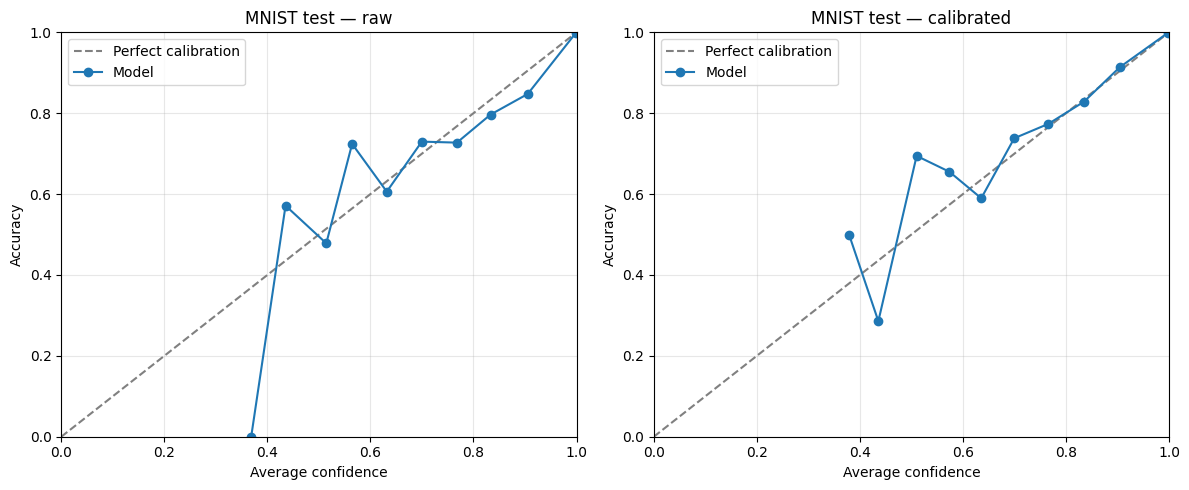

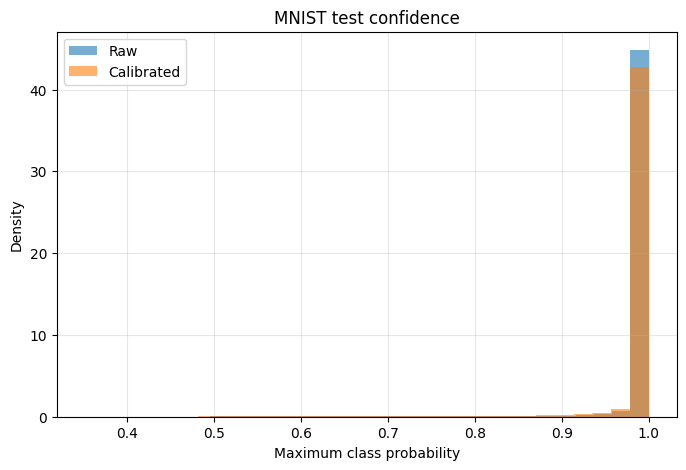

In [ ]:
def plot_reliability_diagram(probabilities, labels, title, num_bins=15):
    confidence, correct = confidence_and_correctness(probabilities, labels)
    bin_edges = np.linspace(0.0, 1.0, num_bins + 1)
    bin_confidences = []
    bin_accuracies = []

    for bin_index in range(num_bins):
        lower = bin_edges[bin_index]
        upper = bin_edges[bin_index + 1]

        if bin_index == num_bins - 1:
            in_bin = (confidence >= lower) & (confidence <= upper)
        else:
            in_bin = (confidence >= lower) & (confidence < upper)

        if np.any(in_bin):
            bin_confidences.append(np.mean(confidence[in_bin]))
            bin_accuracies.append(np.mean(correct[in_bin]))

    plt.plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
    plt.plot(bin_confidences, bin_accuracies, "o-", label="Model")
    plt.xlabel("Average confidence")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(alpha=0.3)
    plt.legend()


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plt.sca(axes[0])
plot_reliability_diagram(
    test_raw_probabilities, y_test, "MNIST test — raw"
)

plt.sca(axes[1])
plot_reliability_diagram(
    test_calibrated_probabilities, y_test, "MNIST test — calibrated"
)

plt.tight_layout()
plt.show()

raw_test_confidence = np.max(test_raw_probabilities, axis=1)
calibrated_test_confidence = np.max(test_calibrated_probabilities, axis=1)

plt.figure(figsize=(8, 5))
plt.hist(raw_test_confidence, bins=30, alpha=0.6, label="Raw", density=True)
plt.hist(
    calibrated_test_confidence,
    bins=30,
    alpha=0.6,
    label="Calibrated",
    density=True,
)
plt.xlabel("Maximum class probability")
plt.ylabel("Density")
plt.title("MNIST test confidence")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**This cell loads the CIFAR-10 dataset and tests the MNIST model on CIFAR-10 images and compares its confidence before and after calibration.**

In [ ]:
(_, _), (x_cifar_raw, _) = tf.keras.datasets.cifar10.load_data()

CIFAR_SUBSET_SIZE = 1000
cifar_rng = np.random.default_rng(SEED)
cifar_indices = cifar_rng.choice(
    len(x_cifar_raw), size=CIFAR_SUBSET_SIZE, replace=False
)
x_cifar_subset = x_cifar_raw[cifar_indices]

cifar_images = tf.convert_to_tensor(x_cifar_subset, dtype=tf.float32) / 255.0
cifar_gray = tf.image.rgb_to_grayscale(cifar_images)
x_cifar = tf.image.resize(cifar_gray, size=(28, 28)).numpy()

cifar_features = feature_model.predict(x_cifar, batch_size=256, verbose=0)
cifar_logits = cifar_features @ output_layer.kernel.numpy()

if output_layer.use_bias:
    cifar_logits += output_layer.bias.numpy()

cifar_raw_probabilities = probabilities_from_logits(cifar_logits)
cifar_calibrated_probabilities = probabilities_from_logits(
    cifar_logits, learned_temperature
)

cifar_raw_confidence = np.max(cifar_raw_probabilities, axis=1)
cifar_calibrated_confidence = np.max(
    cifar_calibrated_probabilities, axis=1
)

confidence_comparison = pd.DataFrame([
    {
        "dataset": "MNIST test",
        "version": "Raw",
        "average_max_probability": float(np.mean(raw_test_confidence)),
        "ece": test_raw_metrics["ece"],
    },
    {
        "dataset": "MNIST test",
        "version": "Calibrated",
        "average_max_probability": float(np.mean(calibrated_test_confidence)),
        "ece": test_calibrated_metrics["ece"],
    },
    {
        "dataset": "CIFAR-10 subset (descriptive only)",
        "version": "Raw",
        "average_max_probability": float(np.mean(cifar_raw_confidence)),
        "ece": np.nan,
    },
    {
        "dataset": "CIFAR-10 subset (descriptive only)",
        "version": "Calibrated",
        "average_max_probability": float(
            np.mean(cifar_calibrated_confidence)
        ),
        "ece": np.nan,
    },
])

display(confidence_comparison.style.format({
    "average_max_probability": "{:.4f}",
    "ece": "{:.4f}",
}))

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2039s 12us/step


,dataset,version,average_max_probability,ece
0,MNIST test,Raw,0.9902,0.0023
1,MNIST test,Calibrated,0.9875,0.0025
2,CIFAR-10 subset (descriptive only),Raw,0.4931,nan
3,CIFAR-10 subset (descriptive only),Calibrated,0.4465,nan


**This cell displays some MNIST and CIFAR-10 images with their predicted labels and confidence scores before and after calibration.**

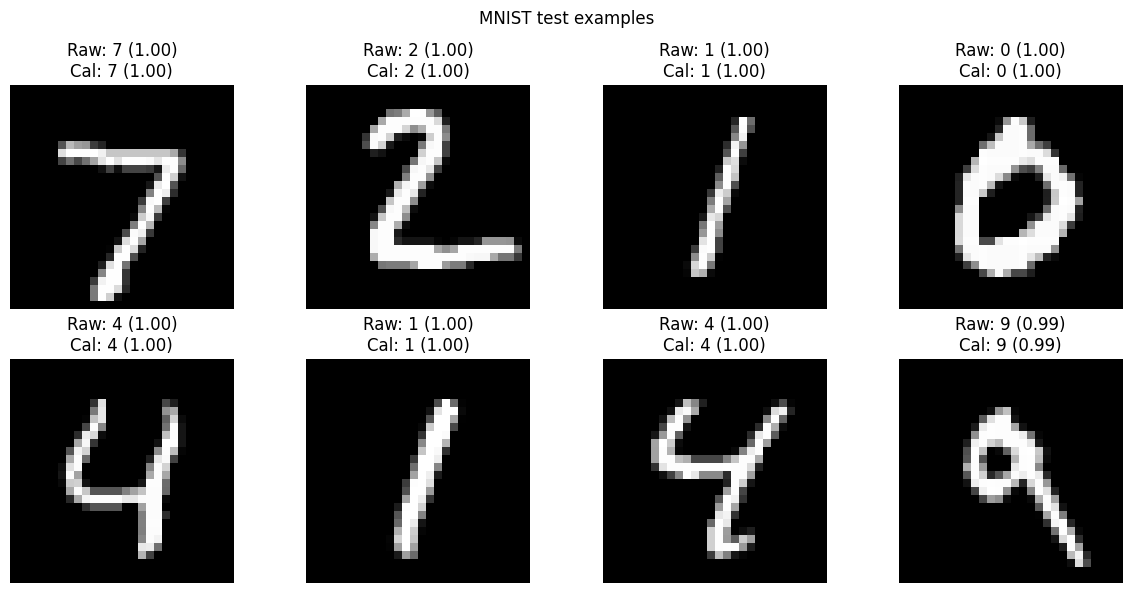

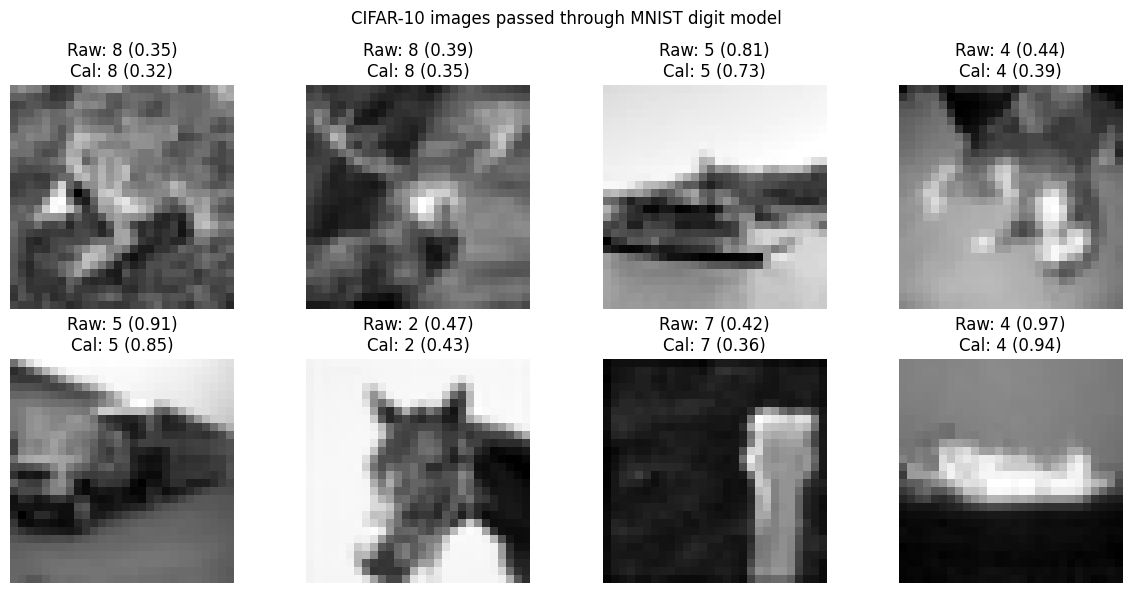

In [ ]:
def show_examples(images, raw_probabilities, calibrated_probabilities,
                  title, count=8):
    count = min(count, len(images))
    columns = 4
    rows = int(np.ceil(count / columns))

    plt.figure(figsize=(12, 3 * rows))

    for i in range(count):
        raw_prediction = int(np.argmax(raw_probabilities[i]))
        calibrated_prediction = int(np.argmax(calibrated_probabilities[i]))
        raw_conf = float(np.max(raw_probabilities[i]))
        calibrated_conf = float(np.max(calibrated_probabilities[i]))

        plt.subplot(rows, columns, i + 1)
        plt.imshow(images[i].squeeze(), cmap="gray")
        plt.title(
            f"Raw: {raw_prediction} ({raw_conf:.2f})\n"
            f"Cal: {calibrated_prediction} ({calibrated_conf:.2f})"
        )
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


show_examples(
    x_test,
    test_raw_probabilities,
    test_calibrated_probabilities,
    "MNIST test examples",
)

show_examples(
    x_cifar,
    cifar_raw_probabilities,
    cifar_calibrated_probabilities,
    "CIFAR-10 images passed through MNIST digit model",
)

**This cell prints the final results, including accuracy, confidence, calibration error, and the effect of temperature calibration.**

In [ ]:
print(f"Temperature fitted on MNIST validation only: {learned_temperature:.4f}")
print(
    f"MNIST test accuracy — raw: {test_raw_metrics['accuracy']:.4f}; "
    f"calibrated: {test_calibrated_metrics['accuracy']:.4f}"
)
print(
    f"MNIST test ECE — raw: {test_raw_metrics['ece']:.4f}; "
    f"calibrated: {test_calibrated_metrics['ece']:.4f}"
)
print(
    "MNIST test average confidence — "
    f"raw: {test_raw_metrics['average_confidence']:.4f}; "
    f"calibrated: {test_calibrated_metrics['average_confidence']:.4f}"
)
print(
    "CIFAR-10 subset average confidence — "
    f"raw: {np.mean(cifar_raw_confidence):.4f}; "
    f"calibrated: {np.mean(cifar_calibrated_confidence):.4f}"
)

if test_calibrated_metrics["ece"] < test_raw_metrics["ece"]:
    print("On this run, calibrated MNIST test ECE is lower.")
elif test_calibrated_metrics["ece"] > test_raw_metrics["ece"]:
    print("On this run, calibrated MNIST test ECE is higher.")
else:
    print("On this run, MNIST test ECE is unchanged.")

print(
    "CIFAR-10 results describe confidence only; they are not CIFAR-10 "
    "accuracy or ECE."
)

Temperature fitted on MNIST validation only: 1.1658
MNIST test accuracy — raw: 0.9893; calibrated: 0.9893
MNIST test ECE — raw: 0.0023; calibrated: 0.0025
MNIST test average confidence — raw: 0.9902; calibrated: 0.9875
CIFAR-10 subset average confidence — raw: 0.4931; calibrated: 0.4465
On this run, calibrated MNIST test ECE is higher.
CIFAR-10 results describe confidence only; they are not CIFAR-10 accuracy or ECE.
